# Exploration of Indicator Data that is used for SHI calculation

The Code in this Jupyter Notebook explores the completeness of soil samples with regard to SHI calculation in the LUCAS SOIL 2018 dataset. Completeness in that case means that all necessary fields of a dataset contain usable values. For each inidicator of interest the samples with usable values (mostly numeric) as well as with missing or other values (NaN, '', '< LOD') are counted and their spread is shown in a histogram (Step 2). After this a more detailed inspection of '< LOD' takes place (Step 3) and finally all samples with NaN values get extracted and saved to a csv for inspection (Step 4).

*Output of this Jupyter Notebook (see output folder after running):*
+ in Step 1: df_all_coi_merged.csv = result of the merge of 4 original datasets (LUCAS), contains all columns of interest, not cleaned yet
+ histograms per indicator --> plotted underneath Step 2
+ in Step 4: df_problem_rows.csv - the dataset containing only the problematic rows that get dropped as one or more indicator column(s) contain no value (NaN)
+ further interesting results (but not super important) are printed directly after cells

*General:*
+ The following columns (or fields) are kept in this Notebook because they might be interesting:
    - 'LC', 'LU', 'LC0_Desc', 'LC1_Desc', 'LU1_Desc', 'TH_LAT', 'TH_LONG'
    - they contain landuse and landcover names and descritpions and coordinates

+ The following columns are essential for SHI calculation and explored in detail:
    - 'BD 0-20', 'pH_CaCl2', 'EC', 'OC', 'P', 'N', 'K', 'Clay', 'erosion_by_water'
    - kept but not further explored: 'Depth' (always 20cm), 'POINT_ID'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Loading and Merging of the 4 Datasets

In a first step 4 datasets are merged as LUCAS data consists of 3 datasets for different information plus 1 dataset on erosion. The datasets share an ID column (POINT_ID) on which they are merged, but they are not of the same length. The indicator Bulk Density 'BD 0-20' is the smallest dataset (6271 samples), the basic soil data is the second smallest dataset (18984 samples), texture and erosion datasets have the same size (27819 samples) and are the largest. Here everything is merged on the the Bulk Density dataset as this indicator is important (it is used for SHI calculaton in more than one way) and cannot be missing. Therefore samples that are present in the basic and texture or erosion dataset will not be considered if their bulk density was not recorded.

- Output: *df_all_coi_merged.csv* - a file where all columns of interest (coi) are merged
- it is used in the second Jupyter Notebook (*data_clean_and_transform.jpynb*)

In [2]:
df_bulk_density = pd.read_csv('01_input/BulkDensity_2018_final-2.csv') # 6271 rows
df_soil_basic = pd.read_csv('01_input/LUCAS-SOIL-2018.csv') # 18984 rows
df_texture = pd.read_csv('01_input/LUCAS_Text_All_10032025.csv') # 27819 rows
df_erosion = pd.read_csv('01_input/LUCAS_soil_erosion.csv') # 27819 rows

In [3]:
# Rename POINTID to POINT_ID where necessary
df_soil_basic = df_soil_basic.rename(columns={'POINTID': 'POINT_ID'})
df_texture = df_texture.rename(columns={'POINTID': 'POINT_ID'})
df_erosion = df_erosion.rename(columns={
    'POINTID': 'POINT_ID',
    'erosion_by_water_t_ha_yr': 'erosion_by_water'
})

In [4]:
# merge the smallest (bulk_desity) and the second smallest (soil_basic) dataframe on POINT_ID
df_bd_basic_merged = df_bulk_density.merge(
    df_soil_basic,
    on='POINT_ID',
    how='left',
    suffixes=('', '_from_soil_basic')  # avoids clashes if columns match
)


# merge the larger (df_texture) into the result of the first merge
df_bd_basic_texture_merged = df_bd_basic_merged.merge(
    df_texture,
    on='POINT_ID',
    how='left',
    suffixes=('', '_from_texture')  # avoids clashes if columns match (NUTS_0 is the only duplicate col name)
)


# merge the other larger (df_erosion) into the result of the second merge
df_bd_basic_texture_erosion_merged = df_bd_basic_texture_merged.merge(
    df_erosion,
    on='POINT_ID',
    how='left',
    suffixes=('', '_from_erosion')  # avoids clashes if columns match (NUTS_0 is the only duplicate col name)
)

columns_of_interest = ['POINT_ID', 'BD 0-20', 'Depth', 'pH_CaCl2', 'EC', 'OC', 'P', 'N', 'K', 'Clay', 'erosion_by_water', 'LC', 'LU', 'LC0_Desc', 'LC1_Desc', 'LU1_Desc', 'TH_LAT', 'TH_LONG']

df_all_coi_merged = df_bd_basic_texture_erosion_merged[df_bd_basic_texture_erosion_merged.columns.intersection(columns_of_interest)]
df_all_coi_merged.to_csv("../output/df_all_coi_merged.csv", index=False)

#check
# print(df_all_coi_merged.info())
# print(df_all_coi_merged.columns)

## Step 2: Dataset Information Service

- two functions are created here that get and print information and produce a histogram for the columns of interest
- '< LOD' values are mostly present in the Phosphor (P) column, the real value is unknown because it was lower than the Level of Detection (LOD)
- the final amount of usable samples depends on how we deal with '< LOD' and samples with missing or wrong information (NaN, negative values)


In [5]:
def get_dataset_information(df, indicator):
    
    indicator_column = df[indicator]
    total_count = len(df)

    # Convert numeric values; all non-numeric become NaN
    numeric_col = pd.to_numeric(indicator_column, errors='coerce')
    # Count all numeric values (exclude NaNs and "< LOD")
    numeric_count = numeric_col.notna().sum()
    # Collect only numeric values for the histogram
    numeric_values = numeric_col.dropna()
    # Count negative numeric values
    neg_count = (numeric_col < 0).sum()
    # Count explicitly empty / NaN cells - ignores "< LOD"
    nan_count = indicator_column.isna().sum()
    # Count "< LOD"
    lod_count = (indicator_column == "< LOD").sum()
    # Min, Max, Median of the numeric values
    minimum = round(numeric_col.min(), 2)
    maximum = round(numeric_col.max(), 2)
    median = round(numeric_col.median(), 2)
    
    # --- Print summary for each indicator ---
    print("\n")
    print(f"Indicator: {indicator}")
    print(f"Total datasets: {total_count}")
    print(f"Numeric values: {numeric_count}")
    print(f"Included Negative values: {neg_count}")
    print(f"Empty cells / NaN: {nan_count}")
    print(f"Count of '< LOD' values: {lod_count}")
    print(f"Min: {minimum}")
    print(f"Max: {maximum}")
    print(f"Median: {median}")

    # --- Return the values for further use ---
    return {
        "total_count": total_count,
        "numeric_count": numeric_count,
        "numeric_values": numeric_values,
        "neg_count": neg_count,
        "nan_count": nan_count,
        "lod_count": lod_count
        }

In [6]:
def create_histograms(info, indicator, unit):

    # Access numeric values for histogram
    numeric_values = info["numeric_values"]
    nan_count = info["nan_count"]
    lod_count = info["lod_count"]
    total_count = info["total_count"]

    plt.figure(figsize=(12,5))

    # Histogram for numeric values, y-axis = count
    counts, bins, patches = plt.hist(numeric_values, bins=20, edgecolor='black', color='tan', density=False)

    # Extra bars for NaN and "< LOD"
    bar_width = bins[1] - bins[0]
    start_pos = bins.max() + bar_width
    plt.bar(start_pos, nan_count, width=bar_width, color='red', edgecolor='black', label='NaN')
    plt.bar(start_pos + bar_width, lod_count, width=bar_width, color='cyan', edgecolor='black', label='< LOD')

    plt.xlabel(f"{indicator} in {unit}")
    plt.ylabel("Count")  # <-- now it clearly shows count, not frequency
    # Include total in the title
    plt.title(f"Histogram for Soil Health Indicator: {indicator} ({unit})\nSize of dataset: {total_count}", fontsize=12)

    # plt.gca() returns the axes object for the current plot and lets you modify the plot more precisely
    ax = plt.gca()

    # adding and styling the X-ticks and extra bars
    num_xticks = 14
    x_ticks = np.linspace(numeric_values.min(), numeric_values.max(), num=num_xticks)
    tick_labels = [f"{t:.2f}" for t in x_ticks]

    extra_positions = [start_pos, start_pos + bar_width]
    extra_labels = ['NaN', '< LOD']

    ax.set_xticks(list(x_ticks) + extra_positions)
    ax.set_xticklabels(tick_labels + extra_labels, rotation=45)

    plt.show()



Indicator: BD 0-20
Total datasets: 6271
Numeric values: 5761
Included Negative values: 2
Empty cells / NaN: 510
Count of '< LOD' values: 0
Min: -0.02
Max: 8.67
Median: 1.14


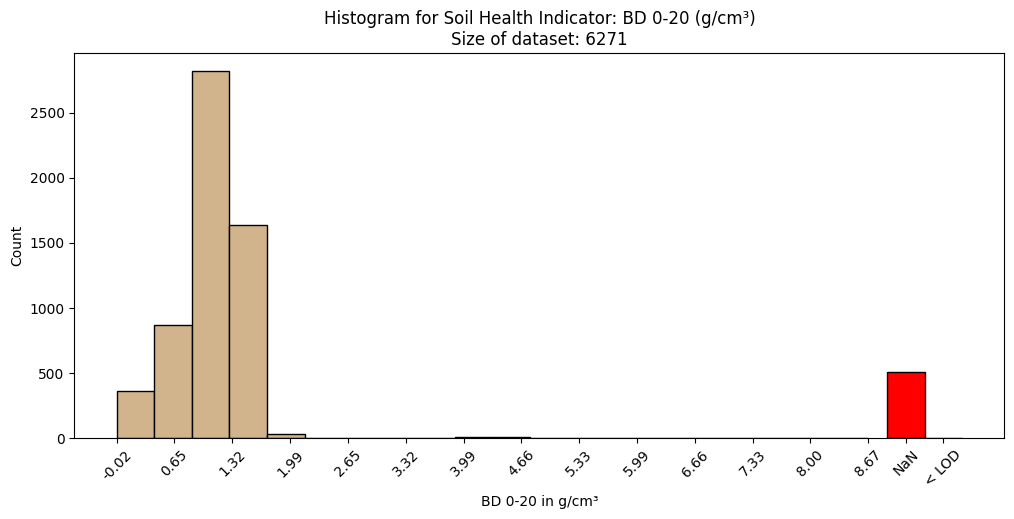



Indicator: pH_CaCl2
Total datasets: 6271
Numeric values: 6171
Included Negative values: 0
Empty cells / NaN: 100
Count of '< LOD' values: 0
Min: 2.8
Max: 8.4
Median: 5.8


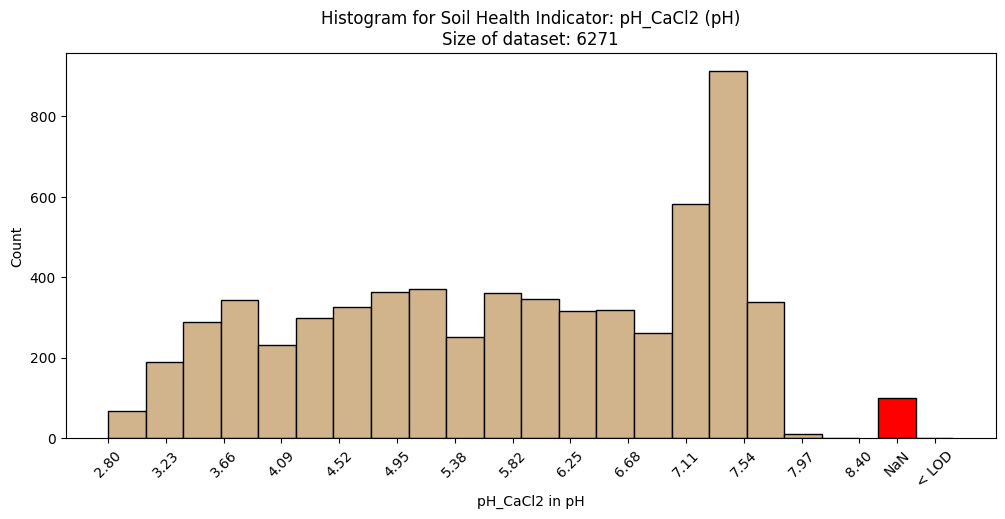



Indicator: EC
Total datasets: 6271
Numeric values: 6168
Included Negative values: 0
Empty cells / NaN: 103
Count of '< LOD' values: 0
Min: 0.24
Max: 421.0
Median: 13.93


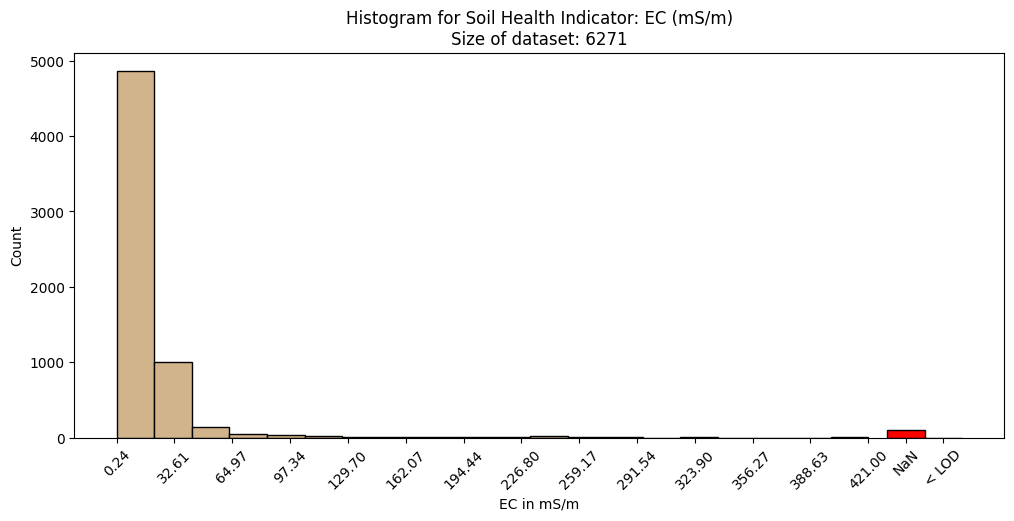



Indicator: OC
Total datasets: 6271
Numeric values: 6166
Included Negative values: 0
Empty cells / NaN: 100
Count of '< LOD' values: 5
Min: 2.2
Max: 540.7
Median: 21.1


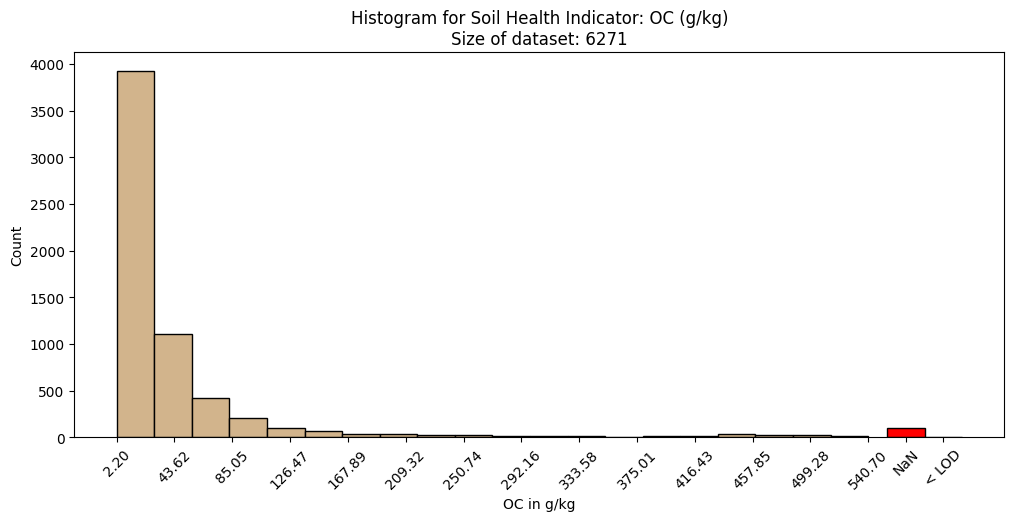



Indicator: P
Total datasets: 6271
Numeric values: 4455
Included Negative values: 0
Empty cells / NaN: 105
Count of '< LOD' values: 1711
Min: 0.3
Max: 325.4
Median: 25.8


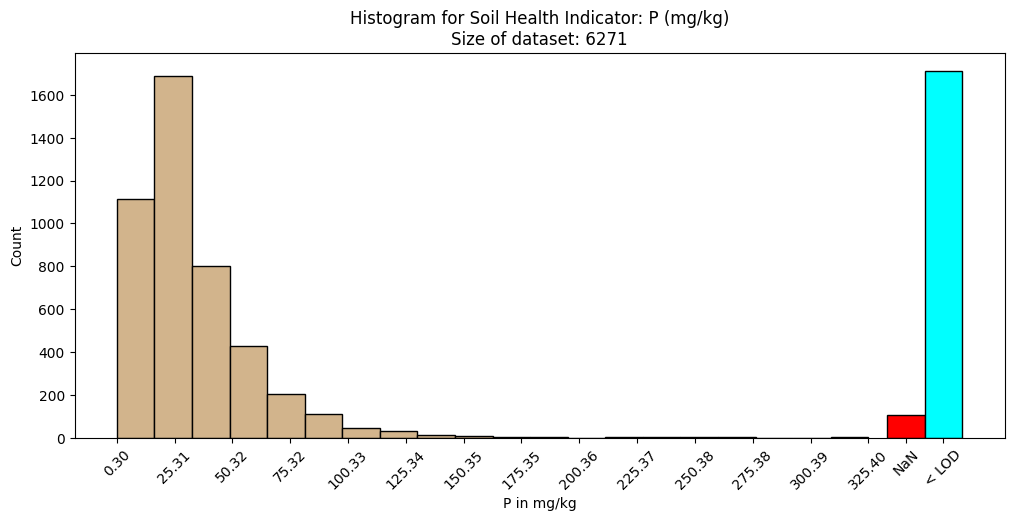



Indicator: N
Total datasets: 6271
Numeric values: 6169
Included Negative values: 0
Empty cells / NaN: 100
Count of '< LOD' values: 2
Min: 0.2
Max: 42.8
Median: 1.9


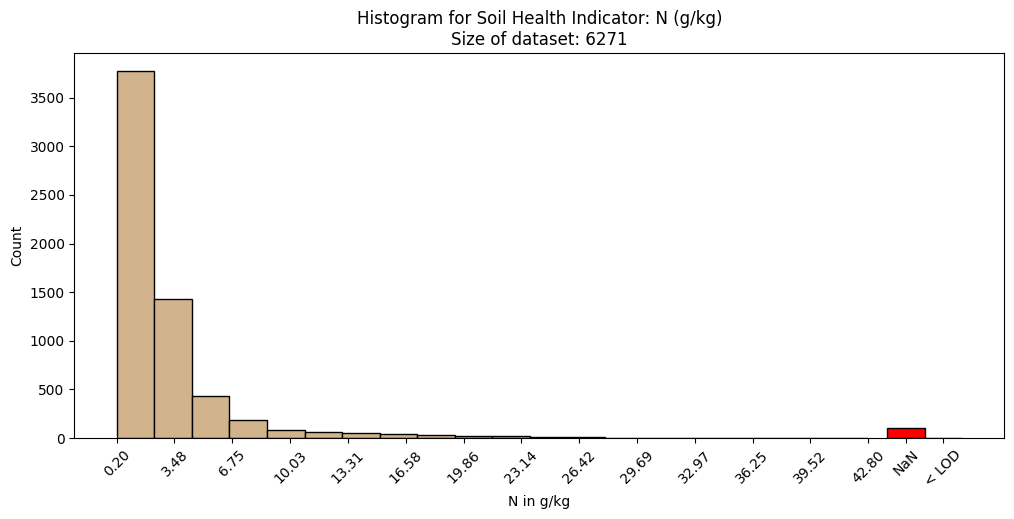



Indicator: K
Total datasets: 6271
Numeric values: 6147
Included Negative values: 0
Empty cells / NaN: 100
Count of '< LOD' values: 24
Min: 6.2
Max: 5093.1
Median: 152.8


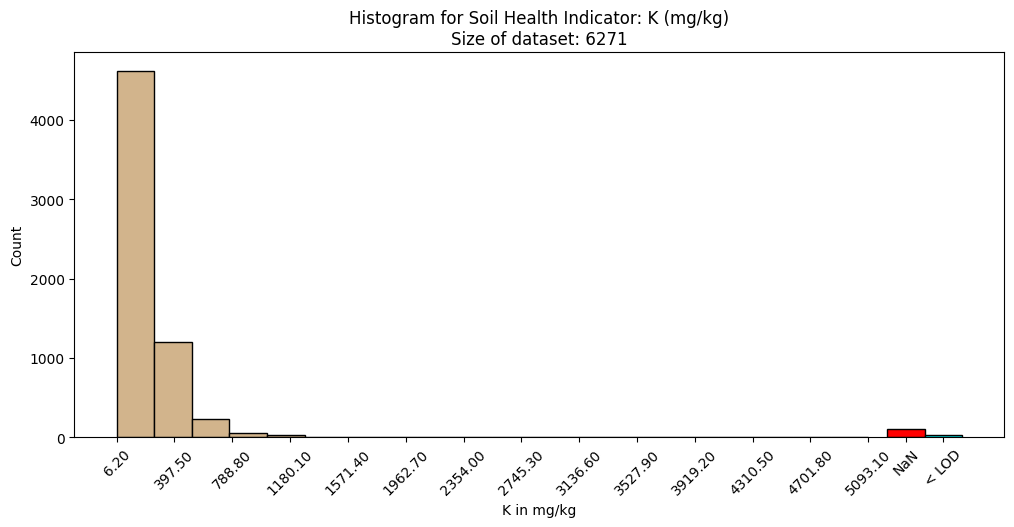



Indicator: Clay
Total datasets: 6271
Numeric values: 6011
Included Negative values: 0
Empty cells / NaN: 260
Count of '< LOD' values: 0
Min: 0.0
Max: 92.0
Median: 18.0


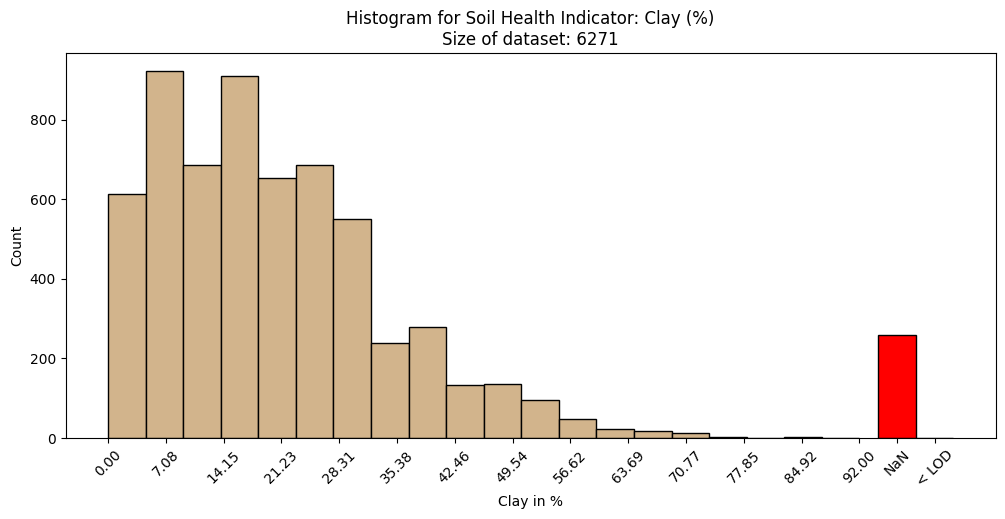



Indicator: erosion_by_water
Total datasets: 6271
Numeric values: 5146
Included Negative values: 0
Empty cells / NaN: 1125
Count of '< LOD' values: 0
Min: 0.0
Max: 180.28
Median: 0.2


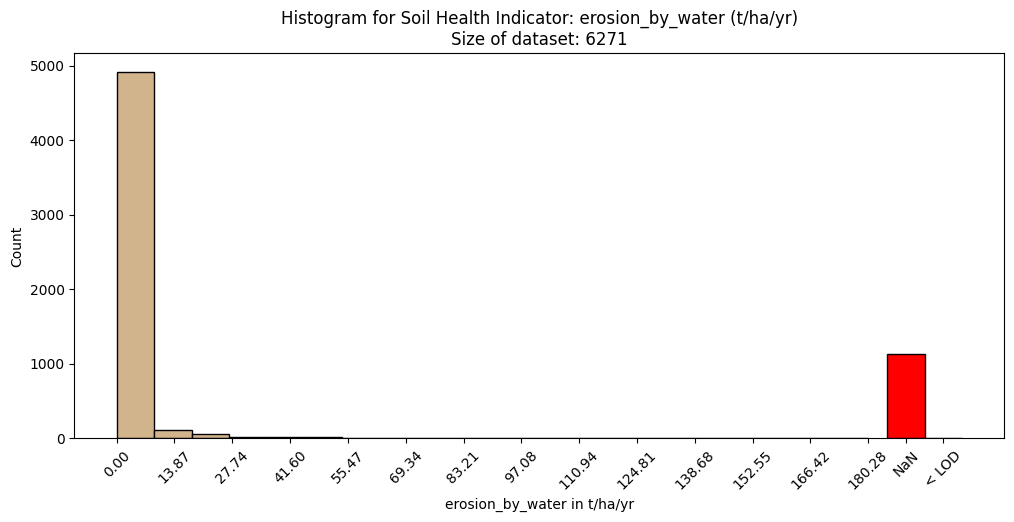

In [7]:
# this part is exchangeable, depending on which dataset, indicators or derived indicators to check
# dataframe and the indicator_units dictionary need to be adjusted

dataframe = df_all_coi_merged
indicators_units = {
    "BD 0-20": "g/cm³",
    "pH_CaCl2": "pH",
    "EC": "mS/m",
    "OC": "g/kg",
    "P": "mg/kg",
    "N": "g/kg",
    "K": "mg/kg",
    "Clay": "%",
    "erosion_by_water": "t/ha/yr"
}

for indicator, unit in indicators_units.items():
    info = get_dataset_information(dataframe, indicator)
    create_histograms(info, indicator, unit)

### Step 3: Exploring the '< LOD' values in P, N, K and OC

In [8]:
df = df_all_coi_merged.copy()

indicator_lods = {
    "OC": 2.0,
    "P": 10.0,
    "N": 0.2,
    "K": 10.0
}

for indicator, lod in indicator_lods.items():
    lod_count = (df[indicator]  == "< LOD").sum()

    df[indicator] = pd.to_numeric(df[indicator], errors="coerce")
    below_lod_count = (df[indicator] < lod).sum()
    
    print(f"Samples with {indicator} numeric values below the LOD {lod}: {below_lod_count}")
    print(f"Samples with '< LOD' values in total for {indicator}:  {lod_count} \n")



Samples with OC numeric values below the LOD 2.0: 0
Samples with '< LOD' values in total for OC:  5 

Samples with P numeric values below the LOD 10.0: 32
Samples with '< LOD' values in total for P:  1711 

Samples with N numeric values below the LOD 0.2: 0
Samples with '< LOD' values in total for N:  2 

Samples with K numeric values below the LOD 10.0: 2
Samples with '< LOD' values in total for K:  24 



### Step 4: Get the NaN rows and export them

In [9]:
df = df_all_coi_merged.copy()

# Columns you want to keep in the output CSV
export_cols = ['POINT_ID', 'Depth', 'BD 0-20', 'pH_CaCl2', 'EC', 
               'OC', 'P', 'N', 'K', 'Clay', 'erosion_by_water']

# Columns to check for "real" NaNs (can be a subset or same as numeric ones)
cols_of_interest = ['BD 0-20', 'pH_CaCl2', 'EC', 'OC', 'P', 'N', 'K', 'Clay', 'erosion_by_water']

# Define function to detect real missing values
def is_real_nan(value):
    return pd.isna(value) or (isinstance(value, str) and value.strip() == "")

# Create mask for rows with at least one real NaN in cols_of_interest
mask_real_nan = df[cols_of_interest].apply(lambda col: col.map(is_real_nan)).any(axis=1)

# Extract problematic rows
df_problem_rows = df.loc[mask_real_nan, export_cols].copy()  # only export the columns you care about

# Save to CSV
df_problem_rows.to_csv("../output/df_problem_rows.csv", index=False)

# Optional: quick summary
print(f"Rows with at least one real NaN (excluding '< LOD'): {len(df_problem_rows)}")


Rows with at least one real NaN (excluding '< LOD'): 1646


#### Check P more detailed as it has most < LOD string values and we need to handle them somehow

In [10]:
# Make a copy of your original DataFrame
df_check = df_all_coi_merged.copy()

# Convert 'P' to numeric, but keep errors='coerce' to turn non-numeric ('< LOD') into NaN
P_numeric = pd.to_numeric(df_check['P'], errors='coerce')

# Filter rows where P is numeric and less than 10
rows_P_below_10 = df_check[P_numeric < 10]

# Median of P in these rows
median_P = pd.to_numeric(rows_P_below_10['P'], errors='coerce').median()
mean_P = pd.to_numeric(rows_P_below_10['P'], errors='coerce').mean()
min_P = pd.to_numeric(rows_P_below_10['P'], errors='coerce').min()
max_P = pd.to_numeric(rows_P_below_10['P'], errors='coerce').max()

print(f"Number of rows where P < 10: {len(rows_P_below_10)}")
print(f"P under 10 median: {median_P}")
print(f"P under 10 median: {mean_P}")
print(f"P under 10 median: {min_P}")
print(f"P under 10 median: {max_P}")

Number of rows where P < 10: 32
P under 10 median: 5.15
P under 10 median: 5.459375
P under 10 median: 0.3
P under 10 median: 9.7
